# Geospatial Analysis

This notebook is used to map the data for geospatial analysis

In [23]:
# imports and setups
import math
from pathlib import Path
import webbrowser

import folium
from folium.plugins import HeatMap, MarkerCluster
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Since VS-Code didn't output the folium Maps properly, I created a helper function to save the map as file and open it automatically in a browser window

In [2]:
# helper function for saving maps
def save_map(geo_map: folium.Map, path: str) -> None:
    """
    Automatically saves the folium.Map as html file and opens it in the webbrowser.
    
    Args:
        geo_map: The created folium map
        path: The name of the file 
    """
    
    file_path = Path(path).resolve()
    geo_map.save(file_path)
    webbrowser.open(file_path.as_uri())

## Loading & Cleaning the Datasets

In [21]:
# storing the paths
colonies_data = Path(r"data\MAPPPD_Antarctic_Penguin_Colonies.csv").resolve()
adelie_data = Path(r"data\NOAA_Adelie_Penguin_Telemetry_1997_2013.csv").resolve()
occurrences_data = Path(r"data\OBIS_Penguin_Occurrences_Global.csv").resolve()

# creating df's
colonies = pd.read_csv(colonies_data)
adelies = pd.read_csv(adelie_data)
occurrences = pd.read_csv(occurrences_data)

# creating gdf's
colonies_gdf = gpd.GeoDataFrame(
    colonies,
    geometry=gpd.points_from_xy(colonies["longitude_epsg_4326"], colonies["latitude_epsg_4326"])
)
 
adelies_gdf = gpd.GeoDataFrame(adelies, geometry=gpd.points_from_xy(adelies['Longitude'], adelies['Latitude']))

occurrences_gdf = gpd.GeoDataFrame(occurrences, geometry=gpd.points_from_xy(occurrences['longitude'], occurrences['latitude']))

#### Colonies

In [4]:
# Penguin Colonies first entries
colonies.head()

,site_name,site_id,cammlr_region,longitude_epsg_4326,latitude_epsg_4326,common_name,day,month,year,season_starting,penguin_count,accuracy,count_type,vantage,reference
0,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,NaN,NaN,1993,1993,2008.0,1.0,nests,ground,Coria N. R. D. Montalti E. F. Rombol&aacute...
1,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,NaN,NaN,1994,1994,1920.0,1.0,nests,NaN,Woehler E. J. and J. P. Croxall (1997). &ldqu...
2,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,NaN,NaN,2004,2004,1880.0,1.0,nests,ground,Coria N. R. D. Montalti E. F. Rombol&aacute...
3,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,25.0,2.0,2011,2010,3079.0,5.0,nests,vhr,Lynch H. J. and M. A. LaRue (2014). &ldquo;Fi...
4,Acuna Island,ACUN,48.2,-44.637,-60.761,chinstrap penguin,28.0,12.0,1983,1983,4000.0,4.0,nests,ground,Poncet S. and J. Poncet (1985). &ldquo;A surv...


In [58]:
# Penguin colonies describe
colonies.info()

<class 'pandas.DataFrame'>
RangeIndex: 5407 entries, 0 to 5406
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   site_name            5407 non-null   str    
 1   site_id              5407 non-null   str    
 2   cammlr_region        5407 non-null   str    
 3   longitude_epsg_4326  5407 non-null   float64
 4   latitude_epsg_4326   5407 non-null   float64
 5   common_name          5407 non-null   str    
 6   day                  3305 non-null   float64
 7   month                3902 non-null   float64
 8   year                 5407 non-null   int64  
 9   season_starting      5407 non-null   int64  
 10  penguin_count        5389 non-null   float64
 11  accuracy             5389 non-null   float64
 12  count_type           5407 non-null   str    
 13  vantage              5101 non-null   str    
 14  reference            5407 non-null   str    
dtypes: float64(6), int64(2), str(7)
memory usage: 633

In [ ]:
# how many different penguin colonies are there and how much colonies do they have? 
colonies['common_name'].value_counts()

common_name
adelie penguin       1870
gentoo penguin       1570
chinstrap penguin    1500
emperor penguin       330
macaroni penguin      124
king penguin           13
Name: count, dtype: int64

#### Adelie Penguins

In [6]:
# Adelie Penguin Telemetry first entries
adelies.head()

,BirdId,Sex,Age,Breed Stage,DateGMT,TimeGMT,Latitude,Longitude,ArgosQuality
0,ADPE1,female,adult,incubation,28/10/1997,7:54:00,-62.171667,-58.445000,2
1,ADPE1,female,adult,incubation,28/10/1997,9:32:00,-62.173333,-58.463333,2
2,ADPE1,female,adult,incubation,28/10/1997,18:15:00,-62.158333,-58.426667,1
3,ADPE1,female,adult,incubation,28/10/1997,19:57:00,-62.175000,-58.441667,2
4,ADPE1,female,adult,incubation,28/10/1997,21:37:00,-62.171667,-58.445000,2


In [48]:
# Adelie Penguin Telemetry describe
adelies.info()

<class 'pandas.DataFrame'>
RangeIndex: 12722 entries, 0 to 12721
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   BirdId        12722 non-null  str    
 1   Sex           12722 non-null  str    
 2   Age           12722 non-null  str    
 3   Breed Stage   12722 non-null  str    
 4   DateGMT       12722 non-null  str    
 5   TimeGMT       12722 non-null  str    
 6   Latitude      12722 non-null  float64
 7   Longitude     12722 non-null  float64
 8   ArgosQuality  12722 non-null  str    
dtypes: float64(2), str(7)
memory usage: 894.6 KB


#### Penguin Occurrences

In [8]:
# Penguin Occurrences first entries
occurrences.head()

,species,scientific_name,latitude,longitude,date,year,month,day,country,locality,depth,basis_of_record,dataset_id,institution,collection,catalog_number
0,Adelie Penguin,Pygoscelis adeliae,-74.780998,169.535004,1.008115e+12,2001.0,12.0,12.0,Antarctica,Inexpressible Island,0.0,HumanObservation,8a1109fe-bf82-42b2-b296-a46c8059b82b,AADC,ARGOS,ARGOS-915-0531
1,Adelie Penguin,Pygoscelis adeliae,-74.337997,165.123993,7.875360e+11,1994.0,12.0,16.0,Antarctica,Edmonson Point,0.0,HumanObservation,8a1109fe-bf82-42b2-b296-a46c8059b82b,AADC,ARGOS,ARGOS-45-0030
2,Adelie Penguin,Pygoscelis adeliae,-67.357002,62.550999,1.074989e+12,2004.0,1.0,25.0,Antarctica,Bechervaise Island,0.0,HumanObservation,8a1109fe-bf82-42b2-b296-a46c8059b82b,AADC,ARGOS,ARGOS-1502-0330
3,Adelie Penguin,Pygoscelis adeliae,-66.448642,47.588606,8.952768e+11,1998.0,5.0,16.0,NaN,"Bechervaise Island, Mawson Coast",NaN,MachineObservation,48cb8624-a221-47ed-9a6d-b99b0bb394e0,NaN,NaN,NaN
4,Adelie Penguin,Pygoscelis adeliae,-74.630216,166.545896,8.494848e+11,1996.0,12.0,2.0,NaN,"Edmonson Point, Ross Sea",NaN,MachineObservation,48cb8624-a221-47ed-9a6d-b99b0bb394e0,NaN,NaN,NaN


In [ ]:
# Penguin Occurrences describe
occurrences.info()

In [72]:
occurrences['species'].value_counts()

species
Adelie Penguin       5000
Emperor Penguin      5000
King Penguin         5000
Macaroni Penguin     5000
Gentoo Penguin       3919
Chinstrap Penguin    3128
Name: count, dtype: int64

## Creating a Map

First I want to map the colonies with a heatmap to see the density of penguin colonies

In [10]:
# defining the range for the map to show
c_map_location = [colonies['latitude_epsg_4326'].mean(), colonies['longitude_epsg_4326'].mean()]

# creating the map
c_map = folium.Map(location=c_map_location, tiles='OpenStreetMap', zoom_start=2)

# adding a heatmap
HeatMap(data=colonies[['latitude_epsg_4326', 'longitude_epsg_4326']],radius=10).add_to(c_map) 

# save & display in webbrowser
save_map(c_map, 'c_map.html')

In [62]:
c_map2 = folium.Map(location=c_map_location, tiles='OpenStreetMap', zoom_start=2)

mc = MarkerCluster()

for idx, row in colonies.iterrows():
    if not math.isnan(row['longitude_epsg_4326']) and not math.isnan(row['latitude_epsg_4326']):
        mc.add_child(folium.Marker([row['latitude_epsg_4326'], row['longitude_epsg_4326']], popup=f'{row['common_name']}, {row['year']}'))

c_map2.add_child(mc)

save_map(c_map2, 'c_map2.html')

In [55]:
# defining the range for map to show
o_map_locations = [occurrences['latitude'].mean(), occurrences['longitude'].mean()]

# creating the map
o_map = folium.Map(location=o_map_locations, tiles='OpenStreetMap', zoom_start=3)

# adding a heatmap
HeatMap(data=occurrences[['latitude', 'longitude']], radius=10).add_to(o_map)

# save & display in browser
save_map(o_map, 'o_map.html')

In [54]:
# creating the telemetry map
a_map_locations = [adelies['Latitude'].mean(), adelies['Longitude'].mean()]

# map
a_map = folium.Map(location=a_map_locations, tiles='OpenStreetMap', zoom_start=3)

# adding a markercluster
for idx, row in adelies.iterrows(): 
    if not math.isnan(row['Longitude']) and not math.isnan(row['Latitude']):
        mc.add_child(folium.Marker([row['Latitude'], row['Longitude']]))

a_map.add_child(mc)
# save & display 
save_map(a_map, 'a_map.html')

### Trying a new approach: Polar view

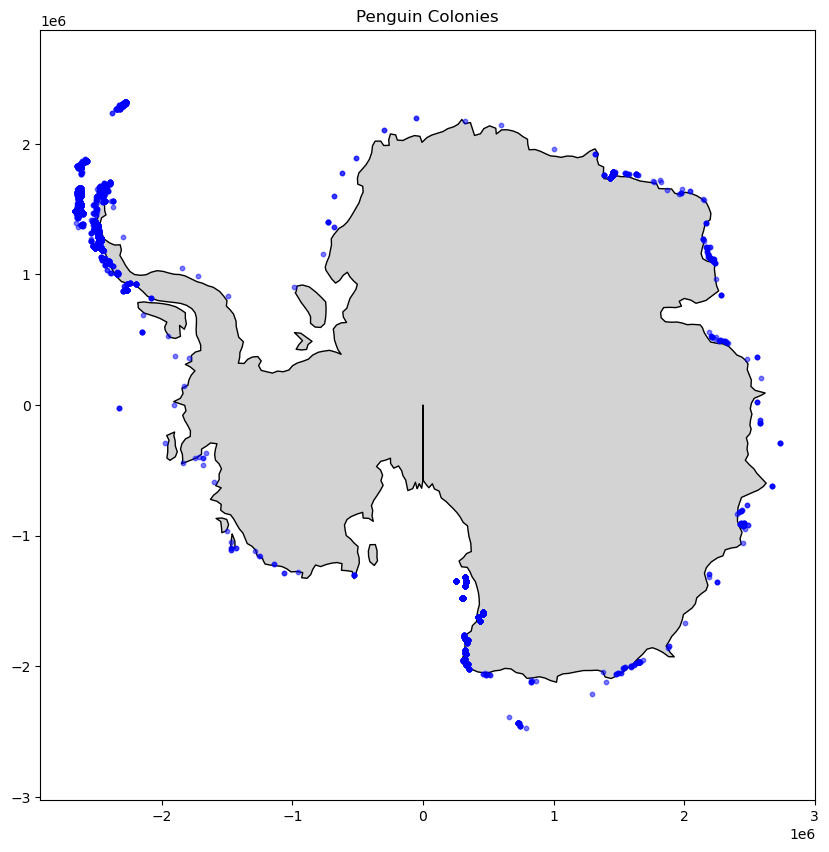

In [53]:
# current format of the gdf
colonies_gdf.set_crs(epsg=4326, inplace=True)

# chanign it to Antarctic Polar Stereographic
colonies_polar = colonies_gdf.to_crs(epsg=3031)

# loading the world map
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

antarctica = world[world['ADMIN'] == 'Antarctica']

antarctica_polar = antarctica.to_crs(epsg=3031)

# plotting it with matplotlib
fig, ax = plt.subplots(figsize=(10,10))

antarctica_polar.plot(ax=ax, color='lightgrey', edgecolor='black')

colonies_polar.plot(ax=ax, markersize=10, color='blue', alpha=0.5)
plt.title('Penguin Colonies')
plt.axis('equal')
plt.show()

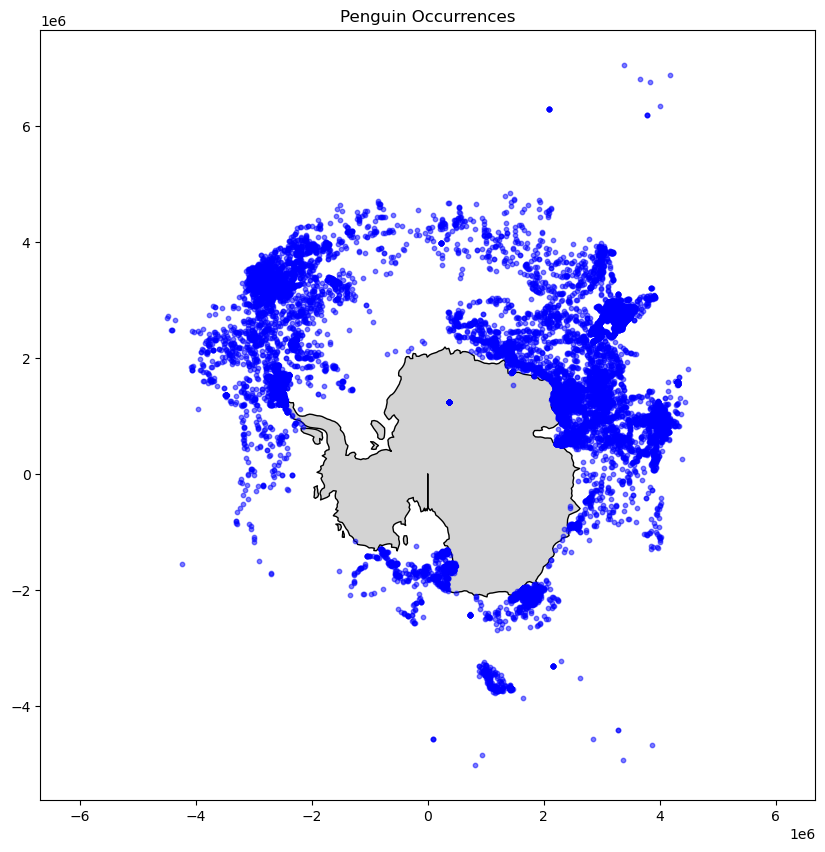

In [29]:
# creating the map for occurences
occurrences_gdf.set_crs(epsg=4326, inplace=True)
occurrences_polar = occurrences_gdf.to_crs(epsg=3031)

# plotting with matplotlib
fig, ax = plt.subplots(figsize=(10,10))

antarctica_polar.plot(ax=ax, color='lightgray', edgecolor='black')
occurrences_polar.plot(ax=ax, color='blue', markersize=10, alpha=0.5)
plt.title('Penguin Occurrences')
plt.axis('equal')
plt.show()

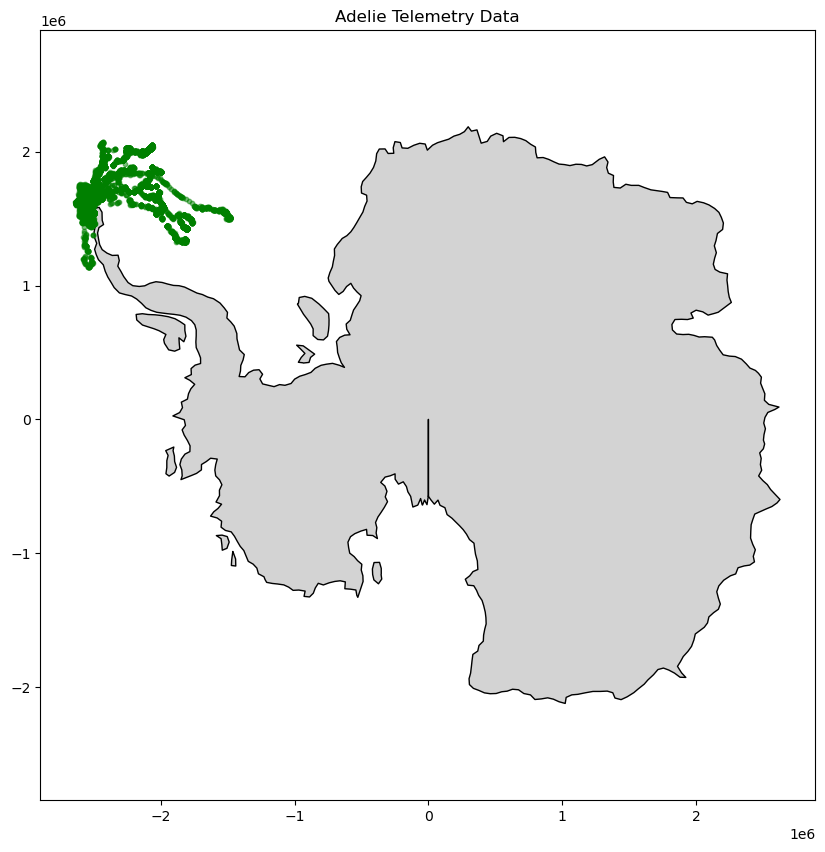

In [30]:
# plotting adelie telemetry
adelies_gdf.set_crs(epsg=4326, inplace=True)
adelies_polar = adelies_gdf.to_crs(epsg=3031)

# plotting 
fig, ax = plt.subplots(figsize=(10,10))

antarctica_polar.plot(ax=ax, color='lightgrey', edgecolor='black')
adelies_polar.plot(ax=ax, color='green', markersize=10, alpha=0.5)

plt.title("Adelie Telemetry Data")
plt.axis('equal')
plt.show()

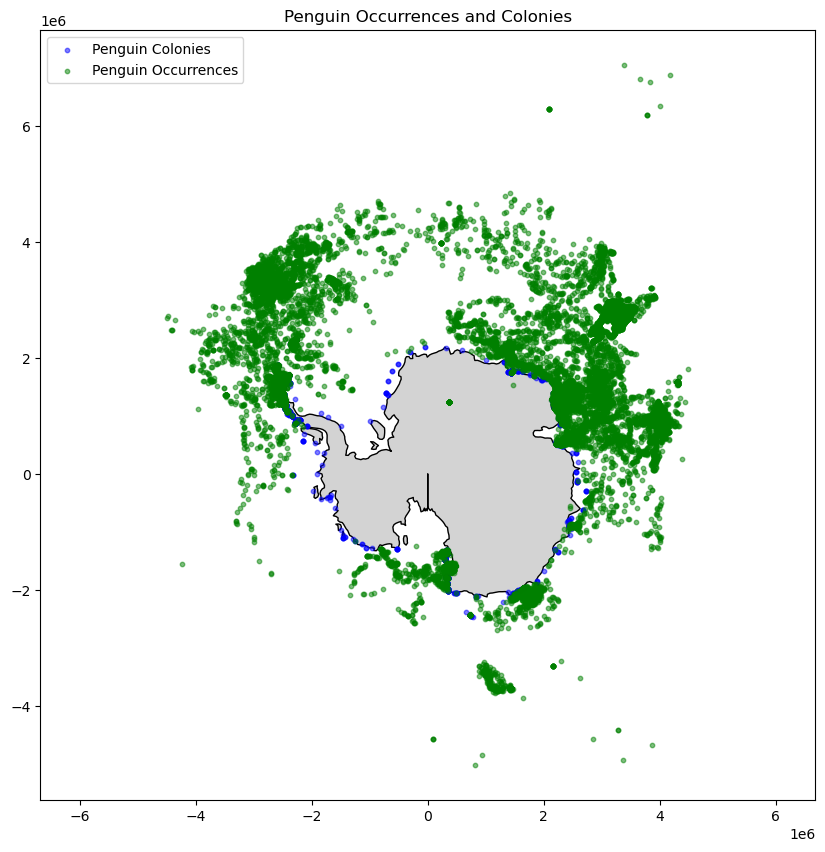

In [41]:
# getting it all together
fig, ax = plt.subplots(figsize=(10,10))

antarctica_polar.plot(ax=ax, color='lightgrey', edgecolor='black')
colonies_polar.plot(ax=ax, color='blue', markersize=10, alpha=0.5, label='Penguin Colonies')
occurrences_polar.plot(ax=ax, color='green', markersize=10, alpha=0.5, label='Penguin Occurrences')

plt.title('Penguin Occurrences and Colonies')
plt.legend()
plt.axis('equal')
plt.show()